In [14]:
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('netflix_titles.csv')

Saving netflix_titles.csv to netflix_titles (3).csv


In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [17]:
df.shape

(8807, 12)

In [18]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [24]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [25]:
df['country'].value_counts().head(10)

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


**Handle missing values**

In [34]:
# Correct way - assign directly to specific columns
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [39]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

df[['date_added', 'year_added']].head(10)

,date_added,year_added
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0
5,2021-09-24,2021.0
6,2021-09-24,2021.0
7,2021-09-24,2021.0
8,2021-09-24,2021.0
9,2021-09-24,2021.0


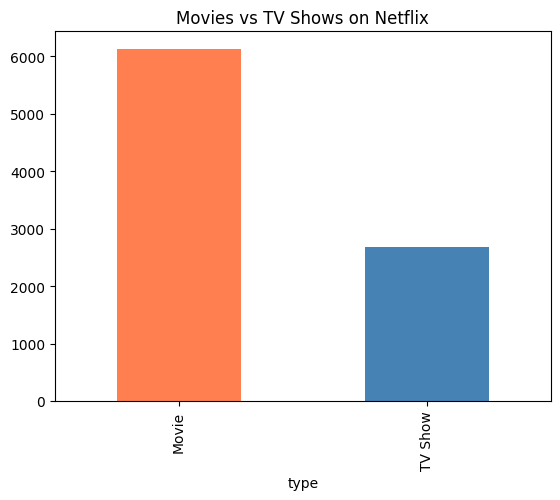

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

# Bar chart - Movies vs TV Shows
df['type'].value_counts().plot(kind='bar', color=['coral','steelblue'])
plt.title('Movies vs TV Shows on Netflix')
plt.show()


**Netflix has more Movies than TV Shows** — Movies make up nearly 70% of
   all content, showing Netflix started as a movie platform.
   

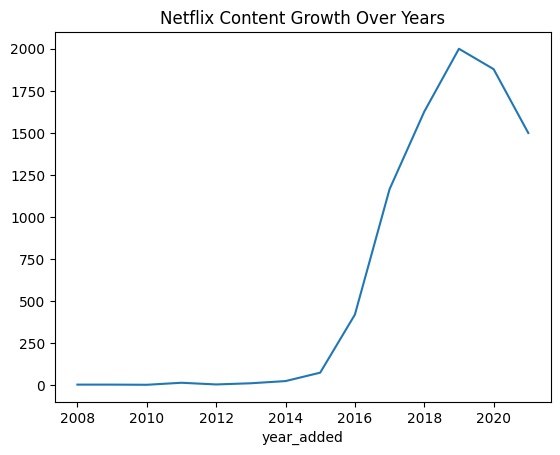

In [44]:
# Line chart - Content added per year
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title('Netflix Content Growth Over Years')
plt.show()

**Netflix content grew rapidly after 2015**

Index(['release_year', 'year_added'], dtype='object')


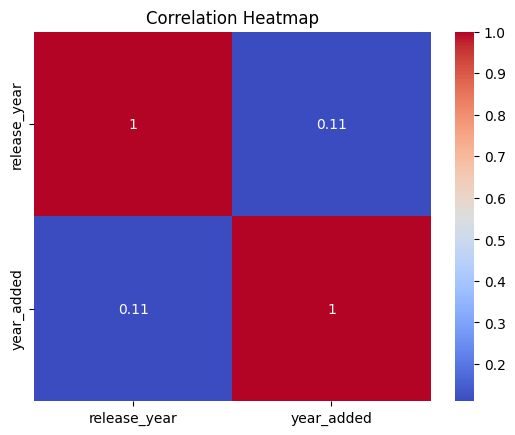

In [45]:
# Heatmap - correlation (if numerical cols exist)
numeric_df = df.select_dtypes(include='number')
print(numeric_df.columns)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

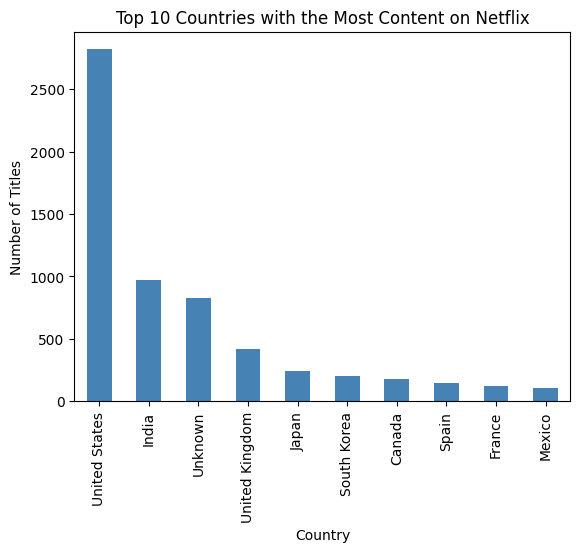

In [48]:
df['country'].value_counts().head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Countries with the Most Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.show()

**USA produces the most content, followed by India** — This shows Netflix's
   global expansion strategy, with India being the fastest growing market.

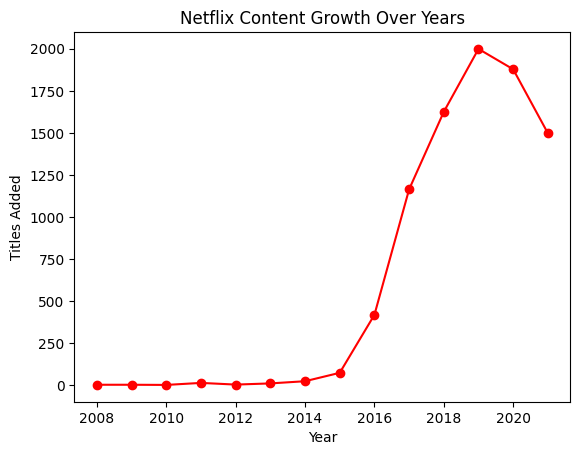

In [49]:
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='red')
plt.title('Netflix Content Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Titles Added')
plt.show()

**Netflix content grew rapidly after 2015** — Content additions peaked
   around 2019-2020, likely due to heavy investment in original content.

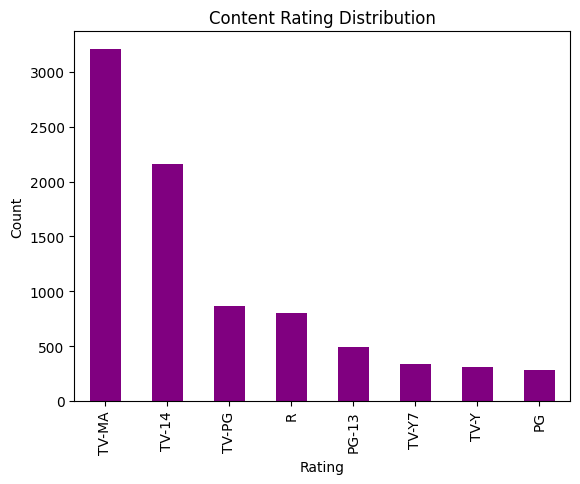

In [50]:
df['rating'].value_counts().head(8).plot(kind='bar', color='purple')
plt.title('Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

**Most content is rated TV-MA** — Netflix primarily targets adult audiences,
   with mature content dominating the platform.

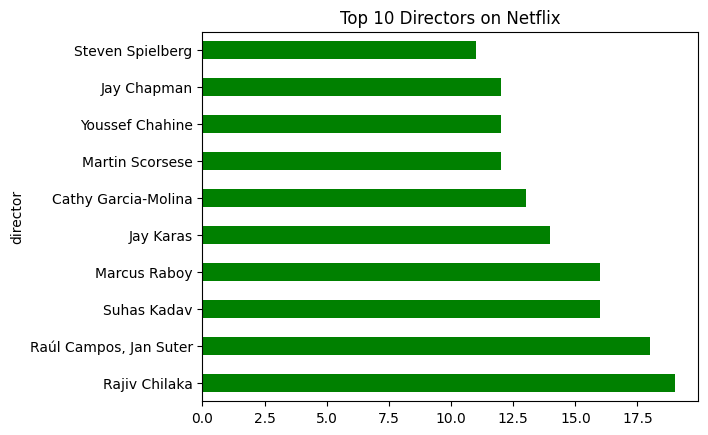

In [51]:
df[df['director'] != 'Unknown']['director'].value_counts().head(10).plot(kind='barh', color='green')
plt.title('Top 10 Directors on Netflix')
plt.show()

 **Rajiv Chilaka is the most featured director with 19 titles** — He is an
   Indian animation director best known for *Chhota Bheem*, which explains
   India's strong presence on the platform.

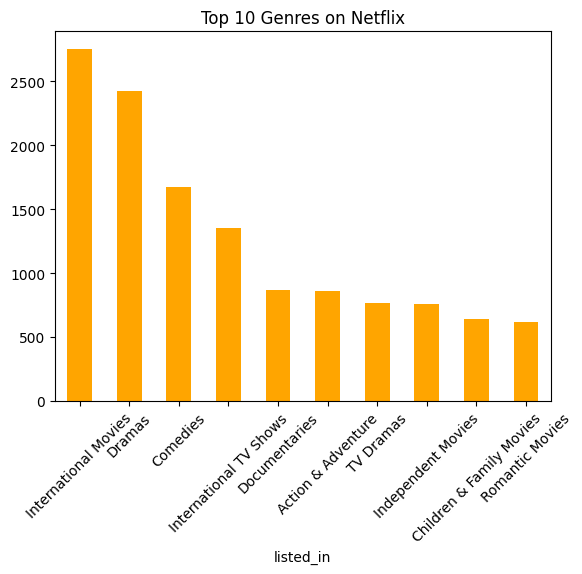

In [52]:
df['listed_in'].str.split(', ').explode().value_counts().head(10).plot(
    kind='bar', color='orange')
plt.title('Top 10 Genres on Netflix')
plt.xticks(rotation=45)
plt.show()

**International Movies is the #1 genre with 2700+ titles** — followed
   closely by Dramas and Comedies. This shows Netflix is truly a global
   platform, heavily investing in non-English international content to
   attract worldwide audiences.